
# Desigualdad CHSH


Realiza un experimento en un ordenador cuántico para demostrar la violación de la desigualdad CHSH con la primitiva Estimador



*Estimación de uso: Dos minutos en un procesador Heron r2 (NOTA: Esto es sólo una estimación. Su tiempo de ejecución puede variar)*



<span id="background" />

## En segundo plano

En este tutorial, realizarás un experimento en un ordenador cuántico para demostrar la violación de la desigualdad CHSH con la primitiva Estimador.

La desigualdad CHSH, llamada así por los autores Clauser, Horne, Shimony y Holt, se utiliza para demostrar experimentalmente el teorema de Bell (1969). Este teorema afirma que las teorías locales de variables ocultas no pueden dar cuenta de algunas consecuencias del entrelazamiento en la mecánica cuántica. La violación de la desigualdad CHSH se utiliza para demostrar que la mecánica cuántica es incompatible con las teorías locales de variables ocultas. Se trata de un experimento importante para comprender los fundamentos de la mecánica cuántica.

El Premio Nobel de Física de 2022 se concedió a Alain Aspect, John Clauser y Anton Zeilinger en parte por sus trabajos pioneros en la ciencia de la información cuántica y, en particular, por sus experimentos con fotones entrelazados que demuestran la violación de las desigualdades de Bell.



<span id="requirements" />

## Requisitos

Antes de empezar este tutorial, asegúrate de que tienes instalado lo siguiente:

*   Qiskit SDK v1.0 o posterior, con soporte [de visualización](/docs/api/qiskit/visualization)
*   Qiskit Runtime (`pip install qiskit-ibm-runtime`) v0.22 o posterior



<span id="setup" />

## Configuración



In [ ]:
# General
import numpy as np

# Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

<span id="step-1-map-classical-inputs-to-a-quantum-problem" />

## Paso 1: Asignar entradas clásicas a un problema cuántico



Para este experimento, crearemos un par enredado en el que mediremos cada qubit en dos bases diferentes. Etiquetaremos las bases del primer qubit $A$ y $a$ y las bases del segundo qubit $B$ y $b$. Esto nos permite calcular la cantidad CHSH $S_1$ :

$$
S_1 = A(B-b) + a(B+b).
$$

Cada observable es $+1$ o $-1$. Claramente, uno de los términos $B\pm b$ debe ser $0$, y el otro debe ser $\pm 2$. Por lo tanto, $S_1 = \pm 2$. El valor medio de $S_1$ debe satisfacer la desigualdad:

$$
|\langle S_1 \rangle|\leq 2.
$$

Expandiendo $S_1$ en términos de $A$, $a$, $B$, y $b$ se obtiene:

$$
|\langle S_1 \rangle| = |\langle AB \rangle - \langle Ab \rangle + \langle aB \rangle + \langle ab \rangle| \leq 2
$$

Puede definir otra cantidad CHSH $S_2$ :

$$
S_2 = A(B+b) - a(B-b),
$$

Esto conduce a otra desigualdad:

$$
|\langle S_2 \rangle| = |\langle AB \rangle + \langle Ab \rangle - \langle aB \rangle + \langle ab \rangle| \leq 2
$$

Si la mecánica cuántica puede describirse mediante teorías locales de variables ocultas, las desigualdades anteriores deben ser ciertas. Sin embargo, como se demuestra en este tutorial, estas desigualdades pueden ser violadas en un ordenador cuántico.  Por lo tanto, la mecánica cuántica no es compatible con las teorías de variables ocultas locales.



Si quiere aprender más teoría, explore [Entanglement in Action](/learning/courses/basics-of-quantum-information/entanglement-in-action/chsh-game) con John Watrous.



Crearás un par enredado entre dos qubits en un ordenador cuántico creando el estado de Bell $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$. Usando la primitiva Estimador, puedes obtener directamente los valores de expectativa necesarios ( $\langle AB \rangle, \langle Ab \rangle, \langle aB \rangle$, y $\langle ab \rangle$ ) para calcular los valores de expectativa de las dos cantidades CHSH $\langle S_1\rangle$ y $\langle S_2\rangle$. Antes de la introducción de la primitiva Estimador, tendrías que construir los valores de expectativa a partir de los resultados de las mediciones.

Medirá el segundo qubit en las bases $Z$ y $X$.  El primer qubit se medirá también en bases ortogonales, pero con un ángulo respecto al segundo qubit, que vamos a barrer entre $0$ y $2\pi$. Como verás, la primitiva Estimator facilita mucho la ejecución de circuitos parametrizados. En lugar de crear una serie de circuitos CHSH, sólo tiene que crear *un* circuito CHSH con un parámetro que especifique el ángulo de medición y una serie de valores de fase para el parámetro.

Por último, analizará los resultados y los comparará con el ángulo de medición. Verá que para cierto rango de ángulos de medición, los valores de expectativa de las cantidades CHSH $|\langle S_1\rangle| > 2$ o $|\langle S_2\rangle| > 2$, lo que demuestra la violación de la desigualdad CHSH.



In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Replace with the API token you copied
api_token = "api token"
my_crn = "crn"
QiskitRuntimeService.save_account(
    channel="ibm_cloud",   
    token=api_token,
    instance=my_crn,         
    set_as_default=True,
    overwrite=True
)

# To run on hardware, select the backend with the fewest number of jobs in the queue

# Initialize the service using the CRN
service = QiskitRuntimeService()

# Find the least busy backend
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)

print(backend.name)

ibm_torino


<span id="create-a-parameterized-chsh-circuit" />

### Crear un circuito CHSH parametrizado

En primer lugar, escribimos el circuito con el parámetro $\theta$, que llamamos `theta`. La [primitiva `Estimator` ](https://docs.quantum-computing.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.EstimatorV2) puede simplificar enormemente la construcción de circuitos y el análisis de resultados al proporcionar directamente valores de expectativa de los observables. Muchos problemas de interés, especialmente para aplicaciones a corto plazo en sistemas ruidosos, pueden formularse en términos de valores de expectativas. `Estimator` ( V2 ) primitiva puede cambiar automáticamente la base de medición en función del observable suministrado.



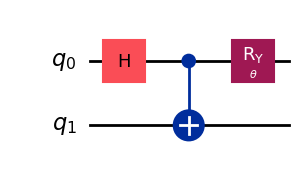

In [ ]:
theta = Parameter("$\\theta$")

chsh_circuit = QuantumCircuit(2)
chsh_circuit.h(0)
chsh_circuit.cx(0, 1)
chsh_circuit.ry(theta, 0)
chsh_circuit.draw(output="mpl", idle_wires=False, style="iqp")

<span id="create-a-list-of-phase-values-to-be-assigned-later" />

### Crear una lista de valores de fase que se asignarán más adelante

Después de crear el circuito CHSH parametrizado, creará una lista de valores de fase que se asignarán al circuito en el siguiente paso. Puede utilizar el siguiente código para crear una lista de 21 valores de fase que van de $0$ a $2 \pi$ con igual espaciado, es decir, $0$, $0.1 \pi$, $0.2 \pi$,..., $1.9 \pi$, $2 \pi$.



In [ ]:
number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)
# Phases need to be expressed as list of lists in order to work
individual_phases = [[ph] for ph in phases]

<span id="observables" />

### Observables

Ahora necesitamos observables a partir de los cuales calcular los valores de expectativa.  En nuestro caso estamos buscando bases ortogonales para cada qubit, dejando que la rotación parametrizada $Y-$ para el primer qubit barra la base de medida casi continuamente con respecto a la base del segundo qubit. Por lo tanto, elegiremos los observables $ZZ$, $ZX$, $XZ$, y $XX$.



In [ ]:
# <CHSH1> = <AB> - <Ab> + <aB> + <ab> -> <ZZ> - <ZX> + <XZ> + <XX>
observable1 = SparsePauliOp.from_list(
    [("ZZ", 1), ("ZX", -1), ("XZ", 1), ("XX", 1)]
)

# <CHSH2> = <AB> + <Ab> - <aB> + <ab> -> <ZZ> + <ZX> - <XZ> + <XX>
observable2 = SparsePauliOp.from_list(
    [("ZZ", 1), ("ZX", 1), ("XZ", -1), ("XX", 1)]
)

<span id="step-2-optimize-problem-for-quantum-hardware-execution" />

## Paso 2: Optimizar el problema para la ejecución en hardware cuántico



Para reducir el tiempo total de ejecución del trabajo, las primitivas de V2 sólo aceptan circuitos y observables que se ajusten a las instrucciones y conectividad admitidas por el sistema de destino (denominados circuitos y observables de arquitectura de conjunto de instrucciones (ISA)).



<span id="isa-circuit" />

### Circuito ISA



In [ ]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

chsh_isa_circuit = pm.run(chsh_circuit)
chsh_isa_circuit.draw(output="mpl", idle_wires=False, style="iqp")

<Image src="/docs/images/tutorials/chsh-inequality/extracted-outputs/9a5561eb-0.avif" alt="Output of the previous code cell" />

<span id="isa-observables" />

### Observables ISA



Del mismo modo, necesitamos transformar los observables para hacerlos compatibles con el backend antes de ejecutar trabajos con [`Runtime Estimator V2`](/docs/api/qiskit-ibm-runtime/estimator-v2#run). Podemos realizar la transformación utilizando el método `apply_layout` the del objeto `SparsePauliOp` .



In [ ]:
isa_observable1 = observable1.apply_layout(layout=chsh_isa_circuit.layout)
isa_observable2 = observable2.apply_layout(layout=chsh_isa_circuit.layout)

<span id="step-3-execute-using-qiskit-primitives" />

## Paso 3: Ejecutar utilizando Qiskit primitives

Para ejecutar todo el experimento en una sola llamada a la función [`Estimator`](https://docs.quantum-computing.ibm.com/api/qiskit-ibm-runtime/qiskit_ibm_runtime.EstimatorV2).



Podemos crear una [Qiskit Runtime `Estimator`](/docs/api/qiskit-ibm-runtime/estimator-v2) primitiva para calcular nuestros valores de expectativa. El método `EstimatorV2.run()` toma un iterable de `primitive unified blocs (PUBs)`. Cada PUB es un iterable con el formato `(circuit, observables, parameter_values: Optional, precision: Optional)`.



In [ ]:
# To run on a local simulator:
# Use the StatevectorEstimator from qiskit.primitives instead.

estimator = Estimator(mode=backend)

pub = (
    chsh_isa_circuit,  # ISA circuit
    [[isa_observable1], [isa_observable2]],  # ISA Observables
    individual_phases,  # Parameter values
)

job_result = estimator.run(pubs=[pub]).result()

<span id="step-4-post-process-and-return-result-in-desired-classical-format" />

## Paso 4: Procesamiento posterior y devolución del resultado en el formato clásico deseado

El estimador devuelve valores de expectativas para los dos observables, $\langle ZZ \rangle - \langle ZX \rangle + \langle XZ \rangle + \langle XX \rangle$ y $\langle ZZ \rangle + \langle ZX \rangle - \langle XZ \rangle + \langle XX \rangle$.



In [ ]:
chsh1_est = job_result[0].data.evs[0]
chsh2_est = job_result[0].data.evs[1]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# results from hardware
ax.plot(phases / np.pi, chsh1_est, "o-", label="CHSH1", zorder=3)
ax.plot(phases / np.pi, chsh2_est, "o-", label="CHSH2", zorder=3)

# classical bound +-2
ax.axhline(y=2, color="0.9", linestyle="--")
ax.axhline(y=-2, color="0.9", linestyle="--")

# quantum bound, +-2√2
ax.axhline(y=np.sqrt(2) * 2, color="0.9", linestyle="-.")
ax.axhline(y=-np.sqrt(2) * 2, color="0.9", linestyle="-.")
ax.fill_between(phases / np.pi, 2, 2 * np.sqrt(2), color="0.6", alpha=0.7)
ax.fill_between(phases / np.pi, -2, -2 * np.sqrt(2), color="0.6", alpha=0.7)

# set x tick labels to the unit of pi
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.xaxis.set_major_locator(tck.MultipleLocator(base=0.5))

# set labels, and legend
plt.xlabel("Theta")
plt.ylabel("CHSH witness")
plt.legend()
plt.show()

<Image src="/docs/images/tutorials/chsh-inequality/extracted-outputs/f6267448-0.avif" alt="Output of the previous code cell" />

En la figura, las líneas y las áreas grises delimitan los límites; las líneas más externas (discontinuas) delimitan los límites cuánticos ( $\pm 2\sqrt{2}$ ), mientras que las líneas internas (discontinuas) delimitan los límites clásicos ( $\pm 2$ ). Se puede observar que hay regiones en las que las cantidades testigo de CHSH superan los límites clásicos. Enhorabuena. ¡Has demostrado con éxito la violación de la desigualdad CHSH en un sistema cuántico real!



<span id="tutorial-survey" />

## Encuesta tutorial

Responda a esta breve encuesta para darnos su opinión sobre este tutorial. Su opinión nos ayudará a mejorar nuestra oferta de contenidos y la experiencia de los usuarios.

[Enlace a la encuesta](https://your.feedback.ibm.com/jfe/form/SV_3xxAgm1SF1wGp9k)



© IBM Corp., 2017-2026